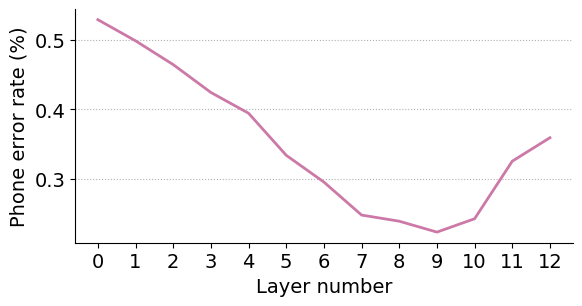

In [42]:
# Phone recognition
%matplotlib inline
import matplotlib.pyplot as plt
import matplotlib
from matplotlib import gridspec
import math
import pandas as pd

matplotlib.rcParams['font.family'] = 'sans-serif'
matplotlib.rcParams['font.serif'] = 'Arial'
matplotlib.rcParams.update({'font.size': 14, 'legend.handleheight':1, 'hatch.linewidth': 1.0,
                           'lines.markersize':5, 'lines.linewidth':2, 'errorbar.capsize': 5})

cm = 1/2.54
color = '#CC79A7'

per = pd.read_csv('/home/engaclew/agent/out/PR_test.txt', header=None, sep=' ')
per.columns = ['layer', 'per']


fig = plt.figure(figsize=(14.5*cm,7.5*cm), constrained_layout=True)
gs = gridspec.GridSpec(1, 4, figure=fig, height_ratios=[1])
ax = fig.add_subplot(gs[0, :])

ax.plot(per['layer'], per['per'], color=color)
ax.set_xticks(per['layer'])

ax.set_axisbelow(True)
ax.grid(visible=True, axis='y', linestyle=':', zorder=0)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

ax.set_ylabel('Phone error rate (%)')
ax.set_xlabel('Layer number')
plt.savefig('/home/engaclew/agent/out/ssl_agent/per_wav2vec.png', dpi=300)
plt.show()

In [ ]:
# Speaker identification

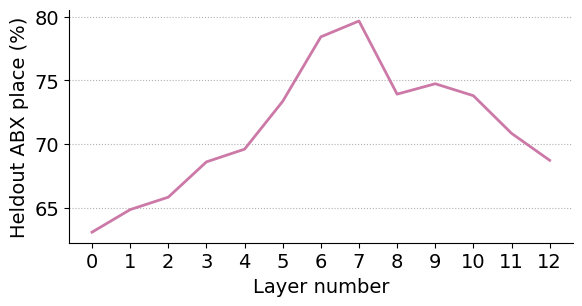

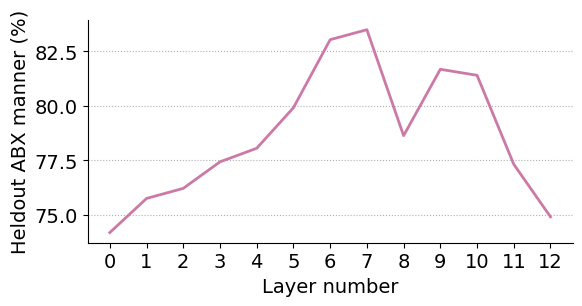

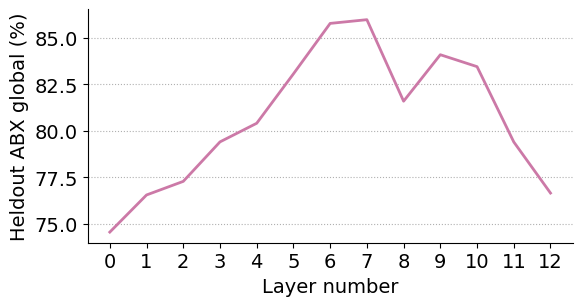

In [62]:
# ABX place
from pathlib import Path
import numpy as np
agent_folder = Path('../out/ssl_agent/cosine/8_speakers_6000_mn')

keys = ['place_feat_seq', 'manner_feat_seq', 'global_feat_seq']
abx_data = pd.DataFrame({'layer': [], 'place_feat_seq': [], 'manner_feat_seq': [], 'global_feat_seq': []})
abx_data['layer'] = list(range(0, 13))
for seed in range(0, 1):
    for i in range(0, 13):
        agent_name = f'8_speakers_6000_mn_layer_{i}_cosine_seed_{seed}'
        agent_path = agent_folder / agent_name / 'results' / f'test_ABX_heldout.csv'
        res = pd.read_csv(agent_path).to_dict('list')
        res = {k:v[0] for k, v in res.items()}
        for key in keys:
            abx_data.loc[abx_data.layer == i, key] = np.mean([v for k, v in res.items() if k.endswith(key)])

# Place
fig = plt.figure(figsize=(14.5*cm,7.5*cm), constrained_layout=True)
gs = gridspec.GridSpec(1, 4, figure=fig, height_ratios=[1])
ax = fig.add_subplot(gs[0, :])

ax.plot(abx_data['layer'], abx_data['place_feat_seq'], color=color)
ax.set_xticks(abx_data['layer'])

ax.set_axisbelow(True)
ax.grid(visible=True, axis='y', linestyle=':', zorder=0)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

ax.set_ylabel('Heldout ABX place (%)')
ax.set_xlabel('Layer number')
plt.savefig('/home/engaclew/agent/out/ssl_agent/abx_place_wav2vec.png', dpi=300)
plt.show()

# Manner
fig = plt.figure(figsize=(14.5*cm,7.5*cm), constrained_layout=True)
gs = gridspec.GridSpec(1, 4, figure=fig, height_ratios=[1])
ax = fig.add_subplot(gs[0, :])

ax.plot(abx_data['layer'], abx_data['manner_feat_seq'], color=color)
ax.set_xticks(abx_data['layer'])

ax.set_axisbelow(True)
ax.grid(visible=True, axis='y', linestyle=':', zorder=0)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

ax.set_ylabel('Heldout ABX manner (%)')
ax.set_xlabel('Layer number')
plt.savefig('/home/engaclew/agent/out/ssl_agent/abx_manner_wav2vec.png', dpi=300)
plt.show()

# Global
fig = plt.figure(figsize=(14.5*cm,7.5*cm), constrained_layout=True)
gs = gridspec.GridSpec(1, 4, figure=fig, height_ratios=[1])
ax = fig.add_subplot(gs[0, :])

ax.plot(per['layer'], abx_data['global_feat_seq'], color=color)
ax.set_xticks(abx_data['layer'])

ax.set_axisbelow(True)
ax.grid(visible=True, axis='y', linestyle=':', zorder=0)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

ax.set_ylabel('Heldout ABX global (%)')
ax.set_xlabel('Layer number')
plt.savefig('/home/engaclew/agent/out/ssl_agent/abx_global_wav2vec.png', dpi=300)
plt.show()